# Data Mining Final - BalanceCascade notebook

Notebook này là bản chạy độc lập của bài Data Mining. Mạch chạy giống report: class imbalance, EDA, preprocessing, BalanceCascade, threshold tuning, controlled cases và seed stability.

Notebook chứa code cần thiết ngay trong các cell bên dưới. Biểu đồ được render trực tiếp bằng `plt.show()`, không cần tạo hoặc mở file ảnh PNG bên ngoài.


## 0. Setup

Import thư viện, tìm thư mục project và khai báo đường dẫn dữ liệu.


In [1]:
%matplotlib inline

from pathlib import Path
import os
import time
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.datasets import make_classification
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    fbeta_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

RANDOM_STATE = 42
pd.set_option("display.max_columns", 30)


In [2]:
def find_project_dir(project_name: str) -> Path:
    cwd = Path.cwd().resolve()
    for base in [cwd, *cwd.parents]:
        if base.name == project_name and (base / "data").exists():
            return base
        nested = base / project_name
        if (nested / "data").exists():
            return nested
    raise FileNotFoundError(f"Không tìm thấy thư mục {project_name}")


PROJECT_DIR = find_project_dir("data-mining-final")
os.chdir(PROJECT_DIR)
DATA_PATH = PROJECT_DIR / "data" / "raw" / "cs-training.csv"
TARGET = "SeriousDlqin2yrs"

print(f"Project dir: {PROJECT_DIR}")
print(f"Data path: {DATA_PATH}")


Project dir: /Users/tadyuh/Documents/Coding Projects/ueh/ueh-finals/data-mining-final
Data path: /Users/tadyuh/Documents/Coding Projects/ueh/ueh-finals/data-mining-final/data/raw/cs-training.csv


## 1. Dữ liệu và class imbalance

Phần này khớp Chương 1 và Chương 2 của report: target, tỷ lệ class `1`, và lý do accuracy dễ gây hiểu nhầm.


In [3]:
df = pd.read_csv(DATA_PATH)
if TARGET not in df.columns:
    raise ValueError(f"Không tìm thấy target {TARGET!r}")

df = df.dropna(subset=[TARGET]).copy()
y = (df[TARGET] == 1).astype(int)
counts = y.value_counts().sort_index()

dataset_summary = pd.DataFrame({
    "rows": [len(df)],
    "columns": [df.shape[1]],
    "target": [TARGET],
    "positive_rate": [float(y.mean())],
    "negative_rate": [float(1 - y.mean())],
})
class_summary = pd.DataFrame({
    "class": counts.index,
    "rows": counts.values,
    "rate": (counts / counts.sum()).round(4).values,
})

display(dataset_summary)
display(class_summary)


,rows,columns,target,positive_rate,negative_rate
0,150000,12,SeriousDlqin2yrs,0.06684,0.93316


,class,rows,rate
0,0,139974,0.9332
1,1,10026,0.0668


In [4]:
lazy_model = pd.DataFrame([
    {
        "model": "Luôn dự đoán class 0",
        "accuracy": float((y == 0).mean()),
        "recall_class_1": 0.0,
        "cach_doc": "Accuracy cao nhưng bỏ sót toàn bộ class 1",
    }
])

display(lazy_model)
print(f"Positive rate class 1: {float(y.mean()):.3%}")


,model,accuracy,recall_class_1,cach_doc
0,Luôn dự đoán class 0,0.93316,0.0,Accuracy cao nhưng bỏ sót toàn bộ class 1


Positive rate class 1: 6.684%


## 2. Code lõi dùng chung

Các cell dưới đây là phần notebook cần để chạy độc lập: preprocessing, model, metric và plotting.


### 2.1. Preprocessing helpers

Target và ID không được đưa vào feature. Imputer/scaler chỉ fit trên tập fit/train.


In [5]:
def make_one_hot_encoder() -> OneHotEncoder:
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def choose_columns(df_in: pd.DataFrame, target: str, max_categorical_cardinality: int, max_missing_rate: float):
    working = df_in.drop(columns=[target], errors="ignore")
    working = working.loc[:, working.isna().mean() <= max_missing_rate]
    numeric_cols = working.select_dtypes(include=["number", "bool"]).columns.tolist()
    categorical_cols, dropped = [], []

    for col in working.columns:
        if col in numeric_cols:
            continue
        if working[col].nunique(dropna=True) <= max_categorical_cardinality:
            categorical_cols.append(col)
        else:
            dropped.append(col)
    return numeric_cols, categorical_cols, dropped


def build_preprocessor(df_in: pd.DataFrame, target: str, max_categorical_cardinality: int = 40, max_missing_rate: float = 0.80):
    auto_drop = [
        col for col in df_in.columns
        if col != target and (col.lower() in {"id", "unnamed: 0"} or col.lower().startswith("unnamed"))
    ]
    if auto_drop:
        print(f"Tự động bỏ các cột ID: {auto_drop}")
        df_in = df_in.drop(columns=auto_drop)
    numeric_cols, categorical_cols, dropped = choose_columns(df_in, target, max_categorical_cardinality, max_missing_rate)
    if not numeric_cols and not categorical_cols:
        raise ValueError("Không còn cột feature dùng được sau khi lọc.")

    transformers = []
    if numeric_cols:
        transformers.append(("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), numeric_cols))
    if categorical_cols:
        transformers.append(("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", make_one_hot_encoder())]), categorical_cols))
    if dropped:
        print(f"Đã bỏ các cột cardinality cao: {dropped}")
    print(f"Dùng {len(numeric_cols)} cột numeric và {len(categorical_cols)} cột categorical.")
    return ColumnTransformer(transformers=transformers, remainder="drop"), numeric_cols + categorical_cols


### 2.2. BalanceCascade và baseline

BalanceCascade giữ toàn bộ minority, lấy mẫu majority theo từng stage, rồi loại dần majority đã phân loại đúng.


In [6]:
def make_adaboost(random_state: int, n_estimators: int = 25) -> AdaBoostClassifier:
    stump = DecisionTreeClassifier(max_depth=1, random_state=random_state)
    try:
        return AdaBoostClassifier(estimator=stump, n_estimators=n_estimators, random_state=random_state)
    except TypeError:
        return AdaBoostClassifier(base_estimator=stump, n_estimators=n_estimators, random_state=random_state)


@dataclass
class SimpleEasyEnsembleClassifier(BaseEstimator, ClassifierMixin):
    n_estimators: int = 6
    adaboost_estimators: int = 25
    random_state: int = RANDOM_STATE

    def fit(self, X: np.ndarray, y_in: np.ndarray):
        rng = np.random.default_rng(self.random_state)
        y_in = np.asarray(y_in)
        pos_idx = np.flatnonzero(y_in == 1)
        neg_idx = np.flatnonzero(y_in == 0)
        if len(pos_idx) == 0 or len(neg_idx) == 0:
            raise ValueError("Cần có đủ cả hai lớp.")
        minority_idx = pos_idx if len(pos_idx) <= len(neg_idx) else neg_idx
        majority_idx = neg_idx if len(pos_idx) <= len(neg_idx) else pos_idx

        self.models_ = []
        for i in range(self.n_estimators):
            sampled_majority = rng.choice(majority_idx, size=len(minority_idx), replace=False)
            train_idx = np.concatenate([minority_idx, sampled_majority])
            model = make_adaboost(self.random_state + i, self.adaboost_estimators)
            model.fit(X[train_idx], y_in[train_idx])
            self.models_.append(model)
        self.classes_ = np.array([0, 1])
        return self

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        return np.array([model.predict_proba(X) for model in self.models_]).mean(axis=0)

    def predict(self, X: np.ndarray) -> np.ndarray:
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)


In [7]:
@dataclass
class SimpleBalanceCascadeClassifier(BaseEstimator, ClassifierMixin):
    n_stages: int = 6
    adaboost_estimators: int = 25
    remove_correct_majority: bool = True
    random_state: int = RANDOM_STATE

    def fit(self, X: np.ndarray, y_in: np.ndarray):
        rng = np.random.default_rng(self.random_state)
        y_in = np.asarray(y_in)
        pos_idx = np.flatnonzero(y_in == 1)
        neg_idx = np.flatnonzero(y_in == 0)
        if len(pos_idx) == 0 or len(neg_idx) == 0:
            raise ValueError("Cần có đủ cả hai lớp.")

        if len(pos_idx) <= len(neg_idx):
            minority_idx, majority_pool, majority_label = pos_idx, neg_idx.copy(), 0
        else:
            minority_idx, majority_pool, majority_label = neg_idx, pos_idx.copy(), 1

        self.models_, self.stage_sizes_ = [], []
        for stage in range(self.n_stages):
            if len(majority_pool) < max(2, len(minority_idx) // 2):
                break
            sampled_majority = rng.choice(majority_pool, size=min(len(minority_idx), len(majority_pool)), replace=False)
            train_idx = np.concatenate([minority_idx, sampled_majority])
            model = make_adaboost(self.random_state + stage, self.adaboost_estimators)
            model.fit(X[train_idx], y_in[train_idx])
            self.models_.append(model)

            if self.remove_correct_majority:
                majority_pred = model.predict(X[majority_pool])
                keep_mask = majority_pred != majority_label
                removed = int((~keep_mask).sum())
                majority_pool = majority_pool[keep_mask]
            else:
                removed = 0
            self.stage_sizes_.append({"stage": stage + 1, "majority_pool_after_stage": len(majority_pool), "majority_removed_this_stage": removed, "minority_count": len(minority_idx)})

        if not self.models_:
            raise ValueError("Không train được stage BalanceCascade nào.")
        self.classes_ = np.array([0, 1])
        return self

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        return np.array([model.predict_proba(X) for model in self.models_]).mean(axis=0)

    def predict(self, X: np.ndarray) -> np.ndarray:
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)


In [8]:
def model_suite(stages: int = 6, adaboost_estimators: int = 25, seed: int = RANDOM_STATE) -> dict[str, object]:
    return {
        "LogReg_balanced": LogisticRegression(max_iter=2000, class_weight="balanced", random_state=seed),
        "RandomForest_balanced": RandomForestClassifier(n_estimators=250, class_weight="balanced_subsample", n_jobs=-1, random_state=seed),
        "EasyEnsemble_simple": SimpleEasyEnsembleClassifier(n_estimators=stages, adaboost_estimators=adaboost_estimators, random_state=seed),
        "BalanceCascade_tuned": SimpleBalanceCascadeClassifier(n_stages=2, adaboost_estimators=10, random_state=seed),
        "BalanceCascade_simple": SimpleBalanceCascadeClassifier(n_stages=stages, adaboost_estimators=adaboost_estimators, random_state=seed),
    }


### 2.3. Metric helpers

F2 được dùng vì bài ưu tiên recall hơn precision, nhưng hai metric này luôn được đọc cùng nhau.


In [9]:
def metric_row(name: str, y_true: np.ndarray, y_score: np.ndarray, runtime: float, threshold: float = 0.5):
    y_pred = (y_score >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        "model": name, "threshold": threshold, "runtime_seconds": runtime,
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "f2": fbeta_score(y_true, y_pred, beta=2, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, y_score),
        "pr_auc": average_precision_score(y_true, y_score),
        "tn": tn, "fp": fp, "fn": fn, "tp": tp,
    }


def threshold_sweep(y_true: np.ndarray, scores_by_model: dict[str, np.ndarray], thresholds=None) -> pd.DataFrame:
    thresholds = np.round(np.arange(0.05, 1.00, 0.05), 2) if thresholds is None else thresholds
    rows = []
    for model_name, score in scores_by_model.items():
        for threshold in thresholds:
            y_pred = (score >= threshold).astype(int)
            rows.append({
                "model": model_name, "threshold": threshold,
                "precision": precision_score(y_true, y_pred, zero_division=0),
                "recall": recall_score(y_true, y_pred, zero_division=0),
                "f1": f1_score(y_true, y_pred, zero_division=0),
                "f2": fbeta_score(y_true, y_pred, beta=2, zero_division=0),
                "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
                "predicted_positive_rate": float(np.mean(y_pred)),
            })
    return pd.DataFrame(rows)


def evaluate_selected_thresholds(y_test: np.ndarray, test_scores_by_model: dict[str, np.ndarray], selected_thresholds: pd.DataFrame, score_column: str):
    rows = []
    for _, selected in selected_thresholds.iterrows():
        model_name = str(selected["model"])
        row = metric_row(model_name, y_test, test_scores_by_model[model_name], np.nan, threshold=float(selected["threshold"]))
        row[f"validation_{score_column}"] = float(selected[score_column])
        rows.append(row)
    return pd.DataFrame(rows).sort_values(f"validation_{score_column}", ascending=False)


### 2.4. Plot helpers

Các hàm plot chỉ render trong notebook bằng `plt.show()`. Không tạo file ảnh.


In [10]:
def show_class_balance(y_in: pd.Series) -> None:
    counts = y_in.value_counts().sort_index()
    plt.figure(figsize=(6, 4))
    counts.plot(kind="bar")
    plt.title("Phân phối target")
    plt.xlabel("Lớp")
    plt.ylabel("Số dòng")
    plt.tight_layout()
    plt.show()


def show_missing(df_in: pd.DataFrame) -> None:
    missing = df_in.isna().mean().sort_values(ascending=False)
    missing = missing[missing > 0].head(25)
    if missing.empty:
        print("Không có missing values.")
        return
    plt.figure(figsize=(8, 4))
    missing.sort_values().plot(kind="barh")
    plt.title("Các cột thiếu dữ liệu nhiều nhất")
    plt.xlabel("Missing rate")
    plt.tight_layout()
    plt.show()


In [11]:
def show_feature_histograms(df_in: pd.DataFrame) -> None:
    feature_cols = [col for col in df_in.select_dtypes(include=["number", "bool"]).columns if col != TARGET and not col.lower().startswith("unnamed")]
    key_cols = [col for col in ["RevolvingUtilizationOfUnsecuredLines", "age", "DebtRatio", "MonthlyIncome", "NumberOfTimes90DaysLate", "NumberOfTime30-59DaysPastDueNotWorse"] if col in feature_cols]
    sample = df_in[key_cols].sample(min(len(df_in), 20000), random_state=RANDOM_STATE)
    axes = sample.hist(figsize=(12, 8), bins=40)
    for ax in np.ravel(axes):
        ax.set_title(ax.get_title(), fontsize=9)
    plt.suptitle("Phân phối một số feature numeric chính", y=1.02)
    plt.tight_layout()
    plt.show()


def show_correlation(df_in: pd.DataFrame) -> None:
    feature_cols = [col for col in df_in.select_dtypes(include=["number", "bool"]).columns if col != TARGET and not col.lower().startswith("unnamed")]
    corr = df_in[feature_cols + [TARGET]].corr(numeric_only=True)
    plt.figure(figsize=(9, 7))
    plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
    plt.colorbar(shrink=0.75, label="Tương quan")
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=90, fontsize=7)
    plt.yticks(range(len(corr.index)), corr.index, fontsize=7)
    plt.title("Heatmap tương quan các biến numeric")
    plt.tight_layout()
    plt.show()


In [12]:
def show_late_payment_rate(df_in: pd.DataFrame) -> pd.DataFrame:
    late_col = "NumberOfTimes90DaysLate"
    rate = df_in.groupby(late_col)[TARGET].agg(["mean", "size"]).reset_index()
    plot_rate = rate[rate["size"] >= 20].head(15)
    plt.figure(figsize=(8, 5))
    plt.bar(plot_rate[late_col].astype(str), plot_rate["mean"], color="#4C78A8")
    plt.xlabel("Số lần trễ hạn 90 ngày")
    plt.ylabel("Tỷ lệ default")
    plt.title("Tỷ lệ default theo số lần trễ hạn 90 ngày")
    plt.tight_layout()
    plt.show()
    return rate


In [13]:
def show_pr_roc_curves(y_test: np.ndarray, scores_by_model: dict[str, np.ndarray]) -> None:
    plt.figure(figsize=(7, 6))
    for name, score in scores_by_model.items():
        precision, recall, _ = precision_recall_curve(y_test, score)
        plt.plot(recall, precision, label=f"{name} AP={average_precision_score(y_test, score):.3f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Đường Precision-Recall")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 6))
    for name, score in scores_by_model.items():
        fpr, tpr, _ = roc_curve(y_test, score)
        plt.plot(fpr, tpr, label=f"{name} AUC={roc_auc_score(y_test, score):.3f}")
    plt.plot([0, 1], [0, 1], "k--", linewidth=1)
    plt.xlabel("False positive rate")
    plt.ylabel("True positive rate")
    plt.title("Đường ROC")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


def show_threshold_sensitivity(thresholds: pd.DataFrame) -> None:
    plt.figure(figsize=(8, 5))
    for model_name, group in thresholds.groupby("model"):
        plt.plot(group["threshold"], group["f2"], marker="o", linewidth=1.4, label=model_name)
    plt.xlabel("Decision threshold")
    plt.ylabel("F2 score")
    plt.title("Độ nhạy F2 theo threshold trên validation")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


In [14]:
def show_confusion_matrices(y_test: np.ndarray, scores_by_model: dict[str, np.ndarray]) -> None:
    fig, axes = plt.subplots(2, 3, figsize=(13, 8), constrained_layout=True)
    axes = axes.ravel()
    for ax, (name, score) in zip(axes, scores_by_model.items()):
        y_pred = (score >= 0.5).astype(int)
        ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=["Lớp 0", "Lớp 1"], cmap="Blues", ax=ax, colorbar=False)
        ax.set_title(name)
    for ax in axes[len(scores_by_model):]:
        ax.axis("off")
    plt.show()


## 3. EDA trên Give Me Some Credit

Phần này khớp Chương 3 của report: class distribution, missing values, feature histogram, correlation và biến trễ hạn 90 ngày.


,column,missing_rate
0,MonthlyIncome,0.198207
1,NumberOfDependents,0.026160


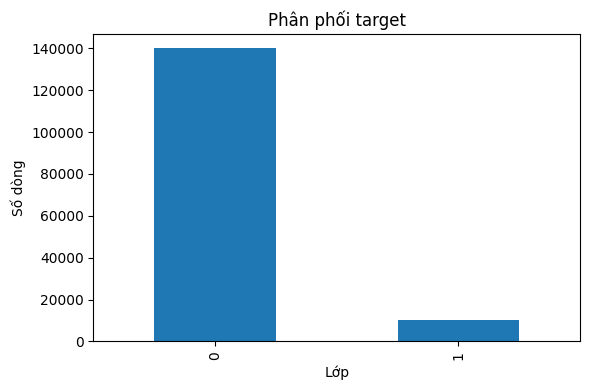

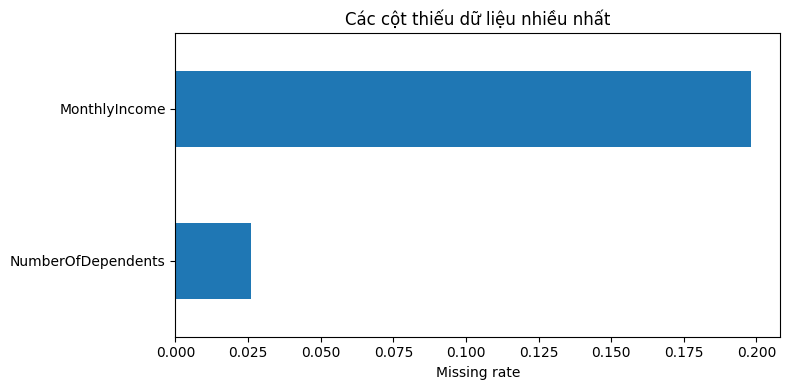

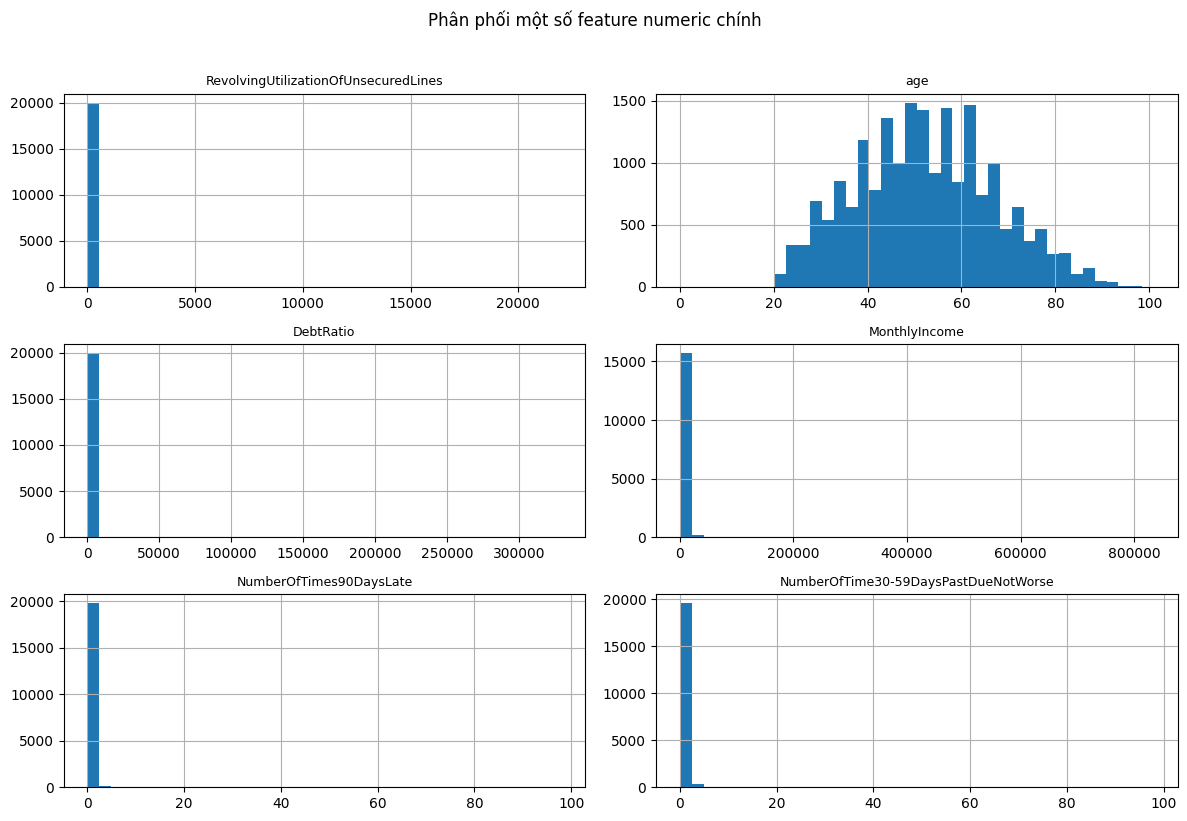

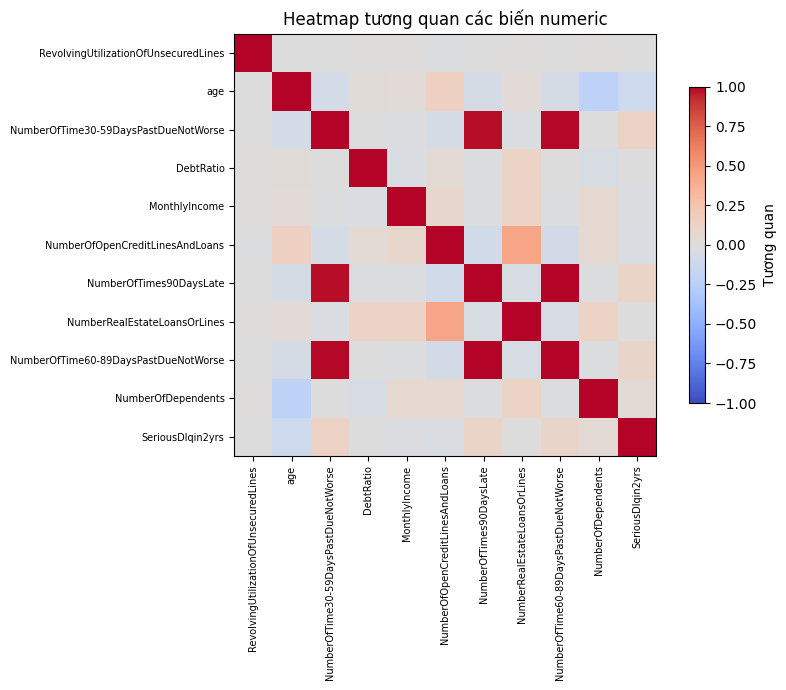

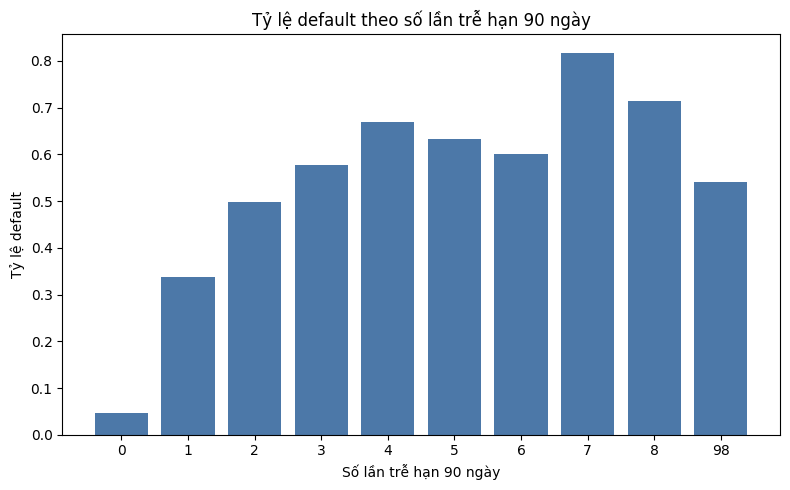

In [15]:
missing_rates = df.isna().mean().sort_values(ascending=False).reset_index()
missing_rates.columns = ["column", "missing_rate"]
missing_rates = missing_rates[missing_rates["missing_rate"] > 0]

display(missing_rates)
show_class_balance(y)
show_missing(df)
show_feature_histograms(df)
show_correlation(df)
default_rate_by_90dayslate = show_late_payment_rate(df)


**Nhận xét nhanh:** dataset mất cân bằng mạnh, `MonthlyIncome` thiếu nhiều nhất, và các biến lịch sử trễ hạn có quan hệ trực quan với rủi ro tín dụng.


## 4. Split dữ liệu và preprocessing

Validation/test giữ phân phối thật. Undersampling chỉ xảy ra trong lúc train model.


In [16]:
X_raw = df.drop(columns=[TARGET])
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y.to_numpy(), test_size=0.25, stratify=y, random_state=RANDOM_STATE
)
X_fit_raw, X_val_raw, y_fit, y_val = train_test_split(
    X_train_raw, y_train, test_size=0.20, stratify=y_train, random_state=RANDOM_STATE
)

train_frame = X_fit_raw.copy()
train_frame[TARGET] = y_fit
preprocessor, used_cols = build_preprocessor(train_frame, TARGET)
X_fit = np.asarray(preprocessor.fit_transform(X_fit_raw), dtype=float)
X_val = np.asarray(preprocessor.transform(X_val_raw), dtype=float)
X_test = np.asarray(preprocessor.transform(X_test_raw), dtype=float)

preprocessing_validation = pd.DataFrame([
    {"check": "dataset_rows_full", "value": len(df), "status": "pass"},
    {"check": "positive_rate_full", "value": float(y.mean()), "status": "pass"},
    {"check": "target_excluded_from_features", "value": TARGET not in used_cols, "status": "pass"},
    {"check": "id_column_excluded", "value": "Unnamed: 0" not in used_cols, "status": "pass"},
    {"check": "train_positive_rate", "value": float(np.mean(y_fit)), "status": "pass"},
    {"check": "validation_positive_rate", "value": float(np.mean(y_val)), "status": "pass"},
    {"check": "test_positive_rate", "value": float(np.mean(y_test)), "status": "pass"},
    {"check": "no_nan_train_after_preprocess", "value": not np.isnan(X_fit).any(), "status": "pass"},
    {"check": "no_nan_validation_after_preprocess", "value": not np.isnan(X_val).any(), "status": "pass"},
    {"check": "no_nan_test_after_preprocess", "value": not np.isnan(X_test).any(), "status": "pass"},
    {"check": "train_matrix_shape", "value": str(X_fit.shape), "status": "pass"},
    {"check": "validation_matrix_shape", "value": str(X_val.shape), "status": "pass"},
    {"check": "test_matrix_shape", "value": str(X_test.shape), "status": "pass"},
    {"check": "used_source_columns", "value": ", ".join(used_cols), "status": "pass"},
])
display(preprocessing_validation)


Tự động bỏ các cột ID: ['Unnamed: 0']
Dùng 10 cột numeric và 0 cột categorical.


,check,value,status
0,dataset_rows_full,150000,pass
1,positive_rate_full,0.06684,pass
2,target_excluded_from_features,True,pass
3,id_column_excluded,True,pass
4,train_positive_rate,0.066844,pass
5,validation_positive_rate,0.066844,pass
6,test_positive_rate,0.066827,pass
7,no_nan_train_after_preprocess,True,pass
8,no_nan_validation_after_preprocess,True,pass
9,no_nan_test_after_preprocess,True,pass


## 5. Train model trên Give Me Some Credit

So sánh các baseline với BalanceCascade ở threshold 0.50.


In [17]:
def evaluate_model_with_validation(name: str, model, X_fit: np.ndarray, y_fit: np.ndarray, X_val: np.ndarray, X_test: np.ndarray, y_test: np.ndarray):
    start = time.perf_counter()
    model.fit(X_fit, y_fit)
    runtime = time.perf_counter() - start
    val_score = model.predict_proba(X_val)[:, 1]
    test_score = model.predict_proba(X_test)[:, 1]
    return metric_row(name, y_test, test_score, runtime), val_score, test_score, model


rows = []
val_scores_by_model, test_scores_by_model, fitted_models = {}, {}, {}
for name, model in model_suite().items():
    print(f"Đang train {name}...")
    row, val_score, test_score, fitted = evaluate_model_with_validation(name, clone(model), X_fit, y_fit, X_val, X_test, y_test)
    rows.append(row)
    val_scores_by_model[name] = val_score
    test_scores_by_model[name] = test_score
    fitted_models[name] = fitted

model_metrics = pd.DataFrame(rows).sort_values(by="pr_auc", ascending=False)
display(model_metrics[["model", "threshold", "precision", "recall", "f1", "f2", "roc_auc", "pr_auc", "fp", "fn", "tp"]])


Đang train LogReg_balanced...
Đang train RandomForest_balanced...


Đang train EasyEnsemble_simple...


Đang train BalanceCascade_tuned...
Đang train BalanceCascade_simple...


,model,threshold,precision,recall,f1,f2,roc_auc,pr_auc,fp,fn,tp
2,EasyEnsemble_simple,0.5,0.191007,0.766161,0.305781,0.478183,0.854761,0.368497,8132,586,1920
1,RandomForest_balanced,0.5,0.579259,0.156026,0.245835,0.182727,0.842947,0.354958,284,2115,391
3,BalanceCascade_tuned,0.5,0.226268,0.681963,0.339795,0.486147,0.832351,0.339899,5844,797,1709
0,LogReg_balanced,0.5,0.176217,0.667598,0.278833,0.428579,0.798937,0.319726,7821,833,1673
4,BalanceCascade_simple,0.5,0.066844,1.000000,0.125313,0.263712,0.758930,0.319528,34984,0,2506


In [18]:
stage_tables = {}
for name, cascade in fitted_models.items():
    if hasattr(cascade, "stage_sizes_"):
        stage_tables[name] = pd.DataFrame(cascade.stage_sizes_)

print("BalanceCascade tuned stages")
display(stage_tables["BalanceCascade_tuned"])
print("BalanceCascade simple stages")
display(stage_tables["BalanceCascade_simple"])


BalanceCascade tuned stages


,stage,majority_pool_after_stage,majority_removed_this_stage,minority_count
0,1,21319,62665,6016
1,2,3531,17788,6016


BalanceCascade simple stages


,stage,majority_pool_after_stage,majority_removed_this_stage,minority_count
0,1,19038,64946,6016
1,2,3898,15140,6016
2,3,2128,1770,6016


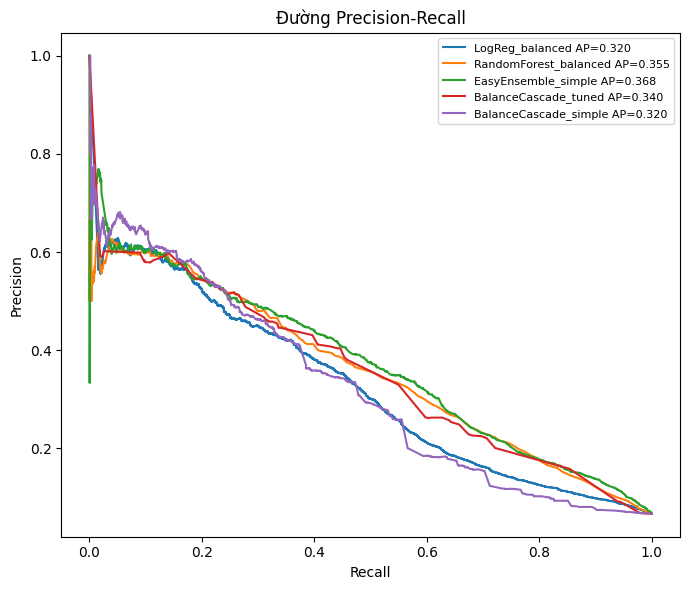

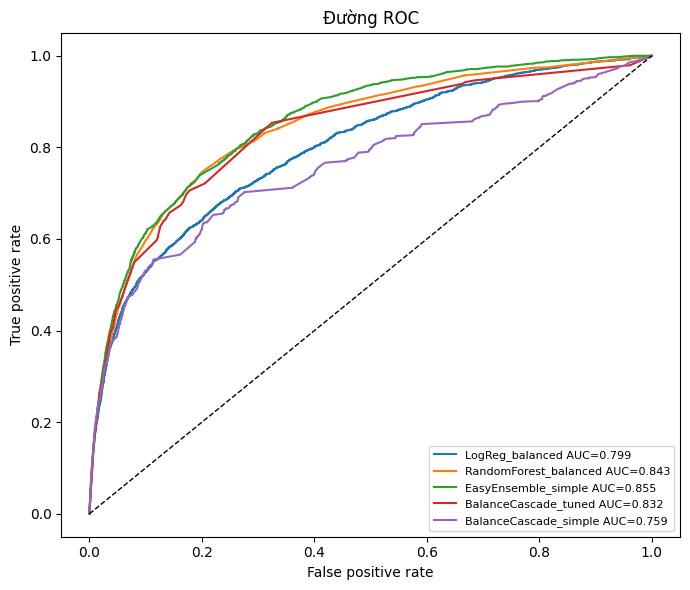

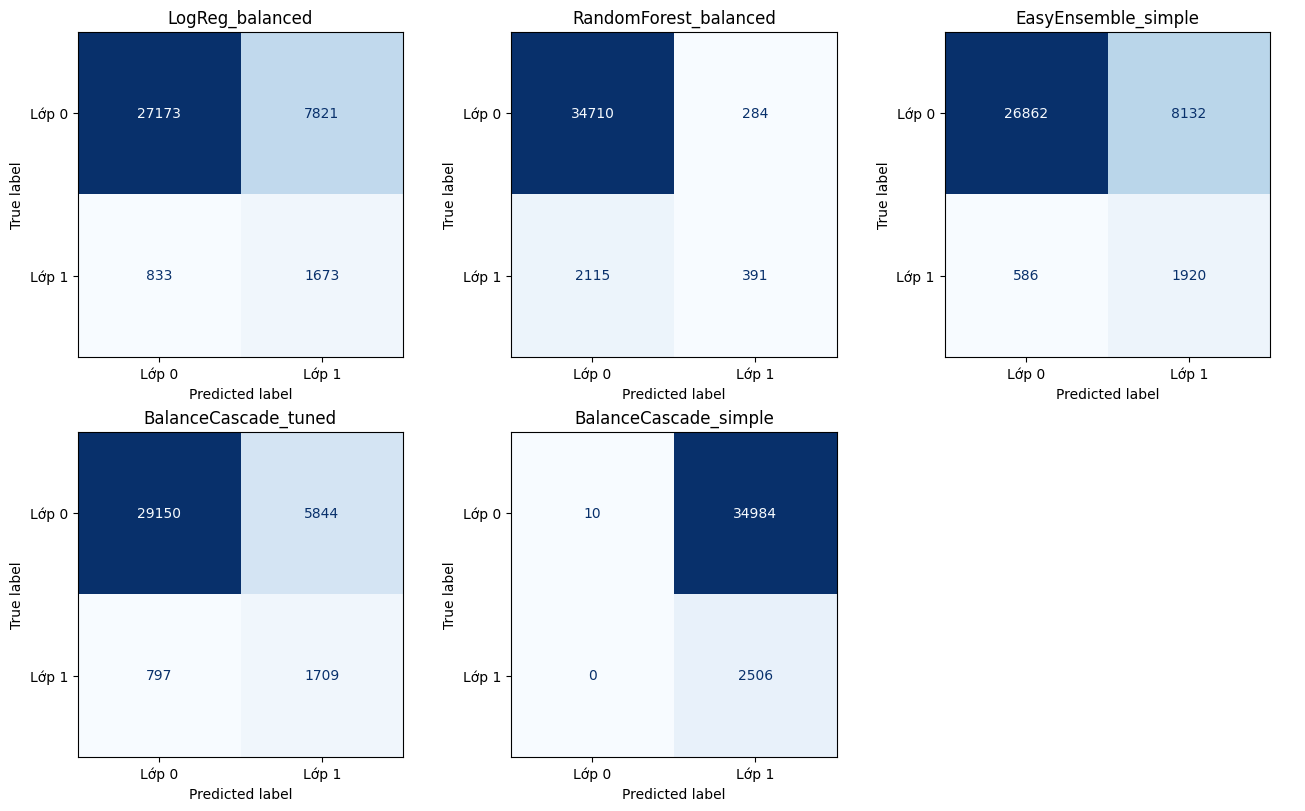

In [19]:
show_pr_roc_curves(y_test, test_scores_by_model)
show_confusion_matrices(y_test, test_scores_by_model)


**Nhận xét nhanh:** BalanceCascade tuned có recall cao hơn RandomForest tại threshold 0.50, nhưng precision thấp hơn. BalanceCascade simple minh họa cấu hình quá nhạy khi recall rất cao nhưng false positive nhiều.


## 6. Threshold tuning

Threshold được chọn trên validation set, sau đó mới đánh giá lại trên test set.


Best threshold by F2 trên validation


,model,threshold,precision,recall,f2,predicted_positive_rate
86,BalanceCascade_simple,0.55,0.102867,0.811170,0.341240,0.527111
67,BalanceCascade_tuned,0.55,0.250393,0.634973,0.485758,0.169511
48,EasyEnsemble_simple,0.55,0.308952,0.589761,0.499044,0.127600
10,LogReg_balanced,0.55,0.239569,0.561170,0.442394,0.156578
20,RandomForest_balanced,0.10,0.245551,0.678856,0.501769,0.184800


Đánh giá lại trên test với threshold đã chọn


,model,threshold,precision,recall,f1,f2,fp,fn,tp
4,RandomForest_balanced,0.10,0.247795,0.672785,0.362191,0.500951,5118,820,1686
2,EasyEnsemble_simple,0.55,0.321722,0.593376,0.417228,0.507647,3135,1019,1487
1,BalanceCascade_tuned,0.55,0.257427,0.639665,0.367113,0.493200,4624,903,1603
3,LogReg_balanced,0.55,0.246425,0.557063,0.341696,0.444898,4269,1110,1396
0,BalanceCascade_simple,0.55,0.102328,0.798085,0.181398,0.338192,17545,506,2000


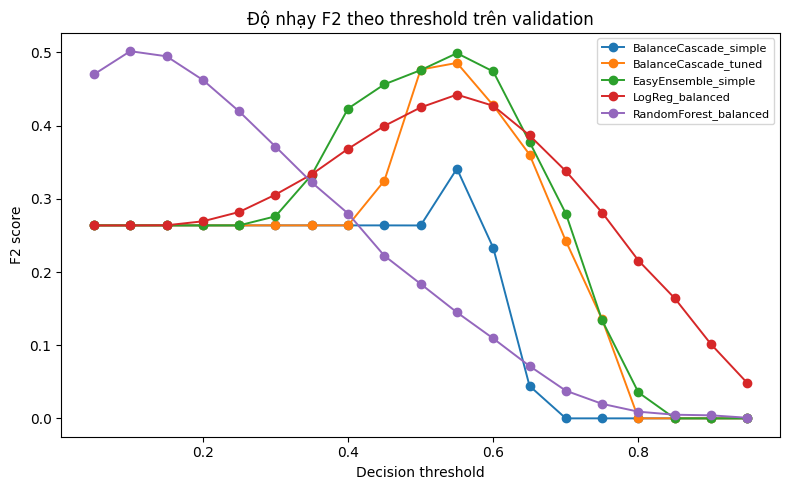

In [20]:
thresholds = threshold_sweep(y_val, val_scores_by_model)
best_f1 = thresholds.sort_values(["model", "f1"], ascending=[True, False]).groupby("model").head(1)
best_f2 = thresholds.sort_values(["model", "f2"], ascending=[True, False]).groupby("model").head(1)
selected_f2 = evaluate_selected_thresholds(y_test, test_scores_by_model, best_f2, "f2")

print("Best threshold by F2 trên validation")
display(best_f2[["model", "threshold", "precision", "recall", "f2", "predicted_positive_rate"]])
print("Đánh giá lại trên test với threshold đã chọn")
display(selected_f2[["model", "threshold", "precision", "recall", "f1", "f2", "fp", "fn", "tp"]])
show_threshold_sensitivity(thresholds)


**Nhận xét nhanh:** sau threshold tuning theo F2, BalanceCascade tuned nằm gần nhóm tốt nhất nhưng không thắng tuyệt đối. Đây là cách đọc thận trọng đúng với report.


## 7. Case mô phỏng

`ideal_separable` là case thuận lợi; `weak_overlap` là case khó để thấy precision có thể giảm mạnh.


In [21]:
def show_controlled_scatter(X: np.ndarray, y_case: np.ndarray, title: str, ax) -> None:
    colors = np.where(y_case == 1, "#E45756", "#4C78A8")
    ax.scatter(X[:, 0], X[:, 1], c=colors, s=12, alpha=0.55, linewidths=0)
    ax.set_xlabel("feature phân biệt 1")
    ax.set_ylabel("feature phân biệt 2")
    ax.set_title(title)


def evaluate_model_on_test(name: str, model, X_train_case: np.ndarray, y_train_case: np.ndarray, X_test_case: np.ndarray, y_test_case: np.ndarray):
    start = time.perf_counter()
    model.fit(X_train_case, y_train_case)
    runtime = time.perf_counter() - start
    return metric_row(name, y_test_case, model.predict_proba(X_test_case)[:, 1], runtime)


In [22]:
def run_controlled_case(case_id: str, class_sep: float, flip_y: float):
    X_case, y_case = make_classification(
        n_samples=8000, n_features=8, n_informative=2, n_redundant=2,
        n_clusters_per_class=2, weights=[0.94, 0.06], class_sep=class_sep,
        flip_y=flip_y, shuffle=False, random_state=RANDOM_STATE,
    )
    X_train_case, X_test_case, y_train_case, y_test_case = train_test_split(
        X_case, y_case, test_size=0.30, stratify=y_case, random_state=RANDOM_STATE
    )
    rows = [evaluate_model_on_test(name, clone(model), X_train_case, y_train_case, X_test_case, y_test_case) for name, model in model_suite().items()]
    frame = pd.DataFrame(rows).sort_values(by="pr_auc", ascending=False)
    frame.insert(0, "case_id", case_id)
    frame.insert(1, "class_sep", class_sep)
    frame.insert(2, "flip_y", flip_y)
    frame.insert(3, "positive_rate", float(np.mean(y_case)))
    return X_case, y_case, frame


,case_id,model,precision,recall,f2,pr_auc
2,ideal_separable,EasyEnsemble_simple,0.612335,0.908497,0.828367,0.865713
0,ideal_separable,RandomForest_balanced,0.937984,0.790850,0.816464,0.902976
1,ideal_separable,LogReg_balanced,0.509158,0.908497,0.785311,0.881962
3,ideal_separable,BalanceCascade_tuned,0.249551,0.908497,0.594525,0.856081
4,ideal_separable,BalanceCascade_simple,0.184100,0.862745,0.496614,0.833758
8,weak_overlap,LogReg_balanced,0.137072,0.576419,0.351251,0.143249
6,weak_overlap,EasyEnsemble_simple,0.175788,0.462882,0.348914,0.258970
9,weak_overlap,BalanceCascade_tuned,0.105296,0.737991,0.335184,0.135725
7,weak_overlap,BalanceCascade_simple,0.107955,0.663755,0.327022,0.149692
5,weak_overlap,RandomForest_balanced,0.767857,0.187773,0.221193,0.350427


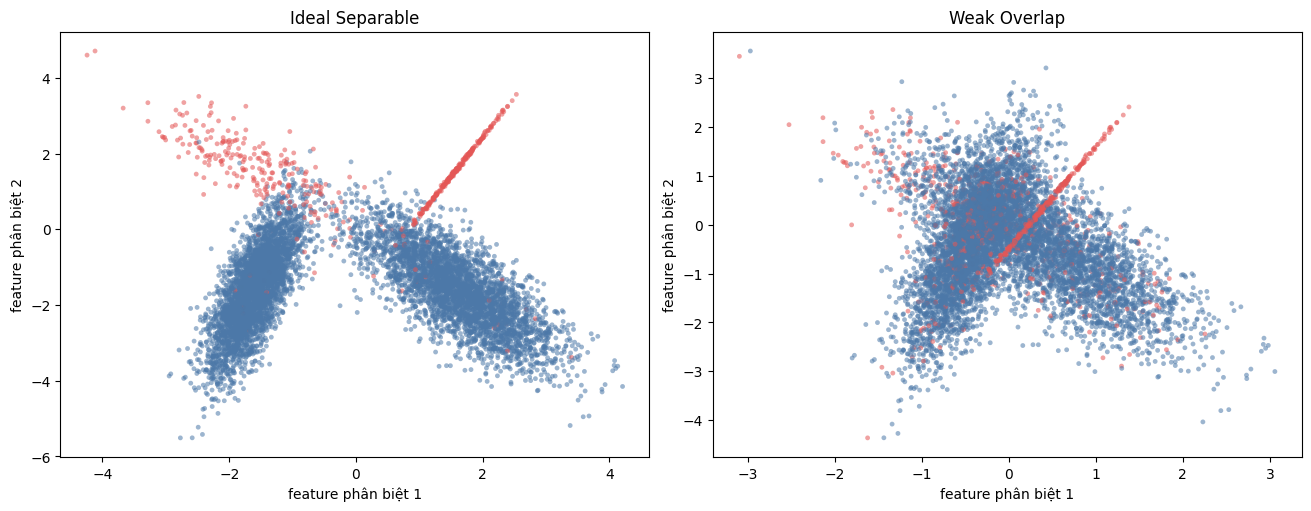

In [23]:
controlled_inputs = [("ideal_separable", 1.60, 0.01), ("weak_overlap", 0.45, 0.08)]
controlled_frames = []
controlled_data = {}
for case_id, class_sep, flip_y in controlled_inputs:
    X_case, y_case, frame = run_controlled_case(case_id, class_sep, flip_y)
    controlled_data[case_id] = (X_case, y_case)
    controlled_frames.append(frame)
controlled_metrics = pd.concat(controlled_frames, ignore_index=True)

display(controlled_metrics[["case_id", "model", "precision", "recall", "f2", "pr_auc"]].sort_values(["case_id", "f2"], ascending=[True, False]))

fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
for ax, (case_id, _, _) in zip(axes, controlled_inputs):
    X_case, y_case = controlled_data[case_id]
    show_controlled_scatter(X_case, y_case, case_id.replace("_", " ").title(), ax)
plt.show()


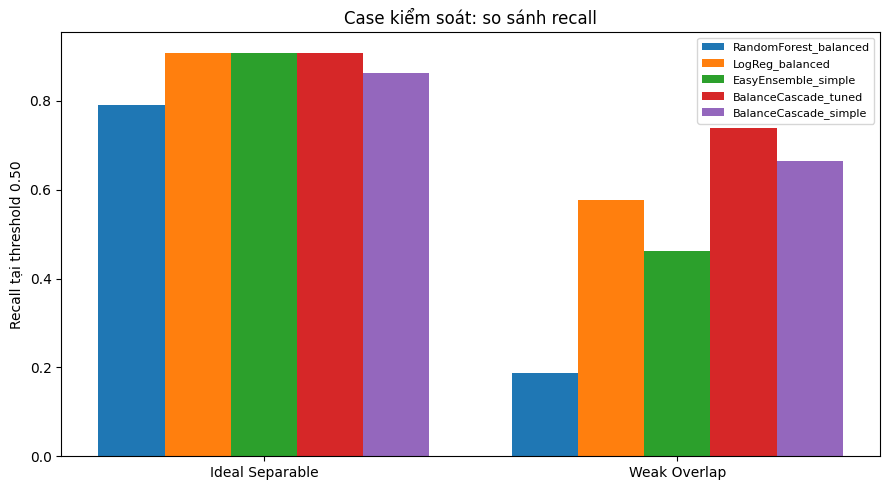

In [24]:
plt.figure(figsize=(9, 5))
x = np.arange(len(controlled_inputs))
model_names = controlled_metrics["model"].drop_duplicates().tolist()
width = min(0.8 / len(model_names), 0.18)
for idx, model_name in enumerate(model_names):
    values = [controlled_metrics[(controlled_metrics["case_id"] == case_id) & (controlled_metrics["model"] == model_name)]["recall"].iloc[0] for case_id, _, _ in controlled_inputs]
    plt.bar(x + (idx - (len(model_names) - 1) / 2) * width, values, width=width, label=model_name)
plt.xticks(x, [case_id.replace("_", " ").title() for case_id, _, _ in controlled_inputs])
plt.ylabel("Recall tại threshold 0.50")
plt.title("Case kiểm soát: so sánh recall")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()


**Nhận xét nhanh:** controlled cases giúp thấy BalanceCascade có thể đẩy recall lên cao, nhưng ở case khó precision giảm rõ. Đây là lý do report không kết luận mô hình thắng tuyệt đối.


## 8. Seed stability

Chạy nhiều seed để xem kết quả có phụ thuộc quá nhiều vào một lần split hay không.


In [25]:
def stability_summary(metrics_in: pd.DataFrame) -> pd.DataFrame:
    summary = metrics_in.groupby("model").agg(
        runs=("seed", "count"), threshold_mean=("threshold", "mean"), threshold_std=("threshold", "std"),
        precision_mean=("precision", "mean"), precision_std=("precision", "std"),
        recall_mean=("recall", "mean"), recall_std=("recall", "std"),
        f2_mean=("f2", "mean"), f2_std=("f2", "std"),
        validation_f2_mean=("validation_f2", "mean"), validation_f2_std=("validation_f2", "std"),
        roc_auc_mean=("roc_auc", "mean"), roc_auc_std=("roc_auc", "std"),
        pr_auc_mean=("pr_auc", "mean"), pr_auc_std=("pr_auc", "std"),
    )
    return summary.reset_index()


def run_one_seed(seed: int) -> list[dict]:
    X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_raw, y.to_numpy(), test_size=0.25, stratify=y, random_state=seed)
    X_fit_s, X_val_s, y_fit_s, y_val_s = train_test_split(X_train_s, y_train_s, test_size=0.20, stratify=y_train_s, random_state=seed)
    train_frame_s = X_fit_s.copy()
    train_frame_s[TARGET] = y_fit_s
    preprocessor_s, _ = build_preprocessor(train_frame_s, TARGET)
    X_fit_s = np.asarray(preprocessor_s.fit_transform(X_fit_s), dtype=float)
    X_val_s = np.asarray(preprocessor_s.transform(X_val_s), dtype=float)
    X_test_s = np.asarray(preprocessor_s.transform(X_test_s), dtype=float)

    val_scores, test_scores, runtimes = {}, {}, {}
    for name, model in model_suite(seed=seed).items():
        start = time.perf_counter()
        model.fit(X_fit_s, y_fit_s)
        runtimes[name] = time.perf_counter() - start
        val_scores[name] = model.predict_proba(X_val_s)[:, 1]
        test_scores[name] = model.predict_proba(X_test_s)[:, 1]

    selected = threshold_sweep(y_val_s, val_scores).sort_values(["model", "f2", "recall"], ascending=[True, False, False]).groupby("model").head(1)
    rows = []
    for _, row in selected.iterrows():
        name = str(row["model"])
        metric = metric_row(name, y_test_s, test_scores[name], runtimes[name], threshold=float(row["threshold"]))
        metric.update({"seed": seed, "validation_precision": float(row["precision"]), "validation_recall": float(row["recall"]), "validation_f2": float(row["f2"])})
        rows.append(metric)
    return rows


In [26]:
seed_rows = []
for seed in [11, 23, 42, 58, 91]:
    print(f"Seed {seed}")
    seed_rows.extend(run_one_seed(seed))

seed_metrics = pd.DataFrame(seed_rows)
seed_summary = stability_summary(seed_metrics)
seed_cols = ["model", "runs", "threshold_mean", "precision_mean", "precision_std", "recall_mean", "recall_std", "f2_mean", "f2_std"]
display(seed_summary[seed_cols].sort_values("f2_mean", ascending=False))


Seed 11
Tự động bỏ các cột ID: ['Unnamed: 0']
Dùng 10 cột numeric và 0 cột categorical.


Seed 23
Tự động bỏ các cột ID: ['Unnamed: 0']
Dùng 10 cột numeric và 0 cột categorical.


Seed 42
Tự động bỏ các cột ID: ['Unnamed: 0']
Dùng 10 cột numeric và 0 cột categorical.


Seed 58
Tự động bỏ các cột ID: ['Unnamed: 0']
Dùng 10 cột numeric và 0 cột categorical.


Seed 91
Tự động bỏ các cột ID: ['Unnamed: 0']
Dùng 10 cột numeric và 0 cột categorical.


,model,runs,threshold_mean,precision_mean,precision_std,recall_mean,recall_std,f2_mean,f2_std
2,EasyEnsemble_simple,5,0.55,0.314450,0.011934,0.594752,0.013454,0.504525,0.007332
4,RandomForest_balanced,5,0.10,0.252337,0.003222,0.668078,0.010454,0.502467,0.005864
1,BalanceCascade_tuned,5,0.52,0.238709,0.019425,0.638478,0.060679,0.475660,0.019910
3,LogReg_balanced,5,0.55,0.247676,0.048753,0.547595,0.064385,0.432784,0.010048
0,BalanceCascade_simple,5,0.55,0.107960,0.009481,0.808343,0.036176,0.350978,0.017209


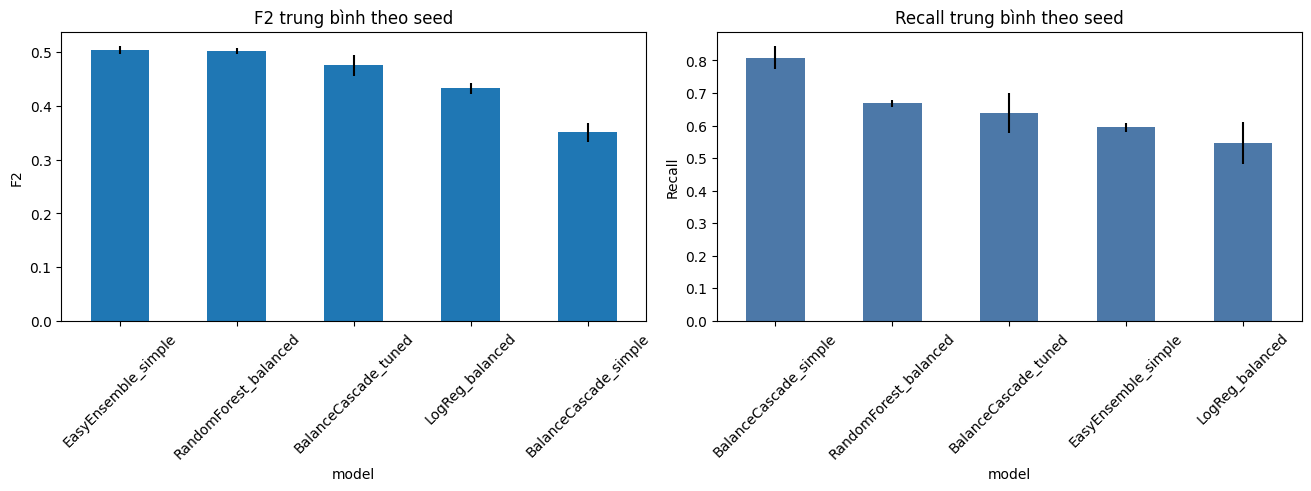

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), constrained_layout=True)
seed_summary.sort_values("f2_mean", ascending=False).plot.bar(x="model", y="f2_mean", yerr="f2_std", ax=axes[0], legend=False)
axes[0].set_title("F2 trung bình theo seed")
axes[0].set_ylabel("F2")
axes[0].tick_params(axis="x", rotation=45)
seed_summary.sort_values("recall_mean", ascending=False).plot.bar(x="model", y="recall_mean", yerr="recall_std", ax=axes[1], legend=False, color="#4C78A8")
axes[1].set_title("Recall trung bình theo seed")
axes[1].set_ylabel("Recall")
axes[1].tick_params(axis="x", rotation=45)
plt.show()


**Nhận xét nhanh:** seed stability cho thấy EasyEnsemble và RandomForest ổn định hơn theo F2 trung bình. BalanceCascade tuned vẫn giữ recall tương đối cao nhưng không phải mô hình thắng tuyệt đối.


## 9. Kết luận notebook

Notebook đã chạy đủ các phần tương ứng với hai file Python: pipeline chính và kiểm tra nhiều seed. Khác với script, notebook không ghi CSV/PNG; bảng và hình được hiển thị trực tiếp trong output cell.
